In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['unit_id','cycle','op1','op2','op3'] + \
          [f'sensor_{i}' for i in range(1,22)]

train = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep="\s+",
    header=None
)

train = train.iloc[:,:26]
train.columns = columns

print(train.head())
print(train.describe())

   unit_id  cycle     op1     op2    op3  sensor_1  sensor_2  sensor_3  \
0        1      1 -0.0007 -0.0004  100.0    518.67    641.82   1589.70   
1        1      2  0.0019 -0.0003  100.0    518.67    642.15   1591.82   
2        1      3 -0.0043  0.0003  100.0    518.67    642.35   1587.99   
3        1      4  0.0007  0.0000  100.0    518.67    642.35   1582.79   
4        1      5 -0.0019 -0.0002  100.0    518.67    642.37   1582.85   

   sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  sensor_15  \
0   1400.60     14.62  ...     521.66    2388.02    8138.62     8.4195   
1   1403.14     14.62  ...     522.28    2388.07    8131.49     8.4318   
2   1404.20     14.62  ...     522.42    2388.03    8133.23     8.4178   
3   1401.87     14.62  ...     522.86    2388.08    8133.83     8.3682   
4   1406.22     14.62  ...     522.19    2388.04    8133.80     8.4294   

   sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0       0.03        392       2388      

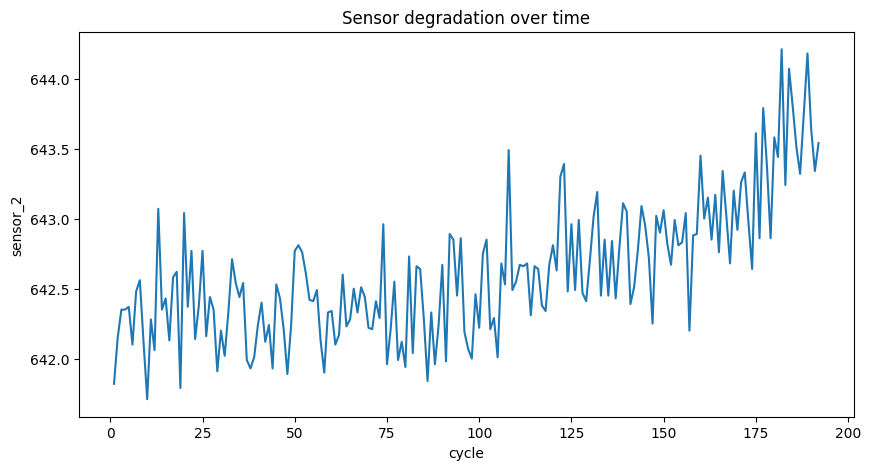

In [2]:
plt.figure(figsize=(10,5))
sns.lineplot(data=train[train["unit_id"]==1], x="cycle", y="sensor_2")
plt.title("Sensor degradation over time")
plt.show()

In [3]:
max_cycle = train.groupby("unit_id")["cycle"].max()

train = train.merge(
    max_cycle.to_frame(name="max_cycle"),
    left_on="unit_id",
    right_index=True
)

train["RUL"] = train["max_cycle"] - train["cycle"]

train.drop("max_cycle", axis=1, inplace=True)

train.head()

,unit_id,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X = train.drop(["unit_id","cycle","RUL"], axis=1)
y = train["RUL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

model = RandomForestRegressor()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 29.16539859462079
